# Notebook 2 — Analytics & Evaluation
**Người 2:** Phân tích kết quả, Đánh giá mô hình, Trực quan hoá

> ️ **Yêu cầu:** Người 1 phải chạy xong và lưu đủ 4 file lên Drive trước khi chạy notebook này.

**Input files từ Người 1:**
- `fp_rules_raw.parquet`
- `fp_association_candidates.parquet`
- `fp_metadata.json`


In [ ]:
# ============================================================
# BƯỚC 0: IMPORT & KHỞI TẠO
# ============================================================
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'matplotlib', 'seaborn', 'pandas', 'numpy'])

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json as _json
import datetime
import math
from pyspark.sql.types import DoubleType
from pyspark.sql.functions import udf

matplotlib.rcParams['figure.dpi'] = 130
sns.set_theme(style='whitegrid', palette='muted')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Spark Session cho Người 2 (chỉ cần đọc parquet, không cần memory cao)
spark = (
 SparkSession.builder
 .appName("FPGrowth_Person2_Analytics")
 .config("spark.sql.adaptive.enabled", "true")
 .config("spark.driver.memory", "4g")
 .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(f" Spark {spark.version} | Thư viện visualization đã sẵn sàng.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Spark 4.0.2 | Thư viện visualization đã sẵn sàng.


In [ ]:
# ============================================================
# BƯỚC 1: TẢI KẾT QUẢ TỪ NGƯỜI 1
# ============================================================
DRIVE_BASE = "/content/drive/MyDrive"
PATH_RULES = f"{DRIVE_BASE}/fp_rules_raw.parquet"
PATH_CANDIDATES = f"{DRIVE_BASE}/fp_association_candidates.parquet"
PATH_METADATA = f"{DRIVE_BASE}/fp_metadata.json"
INPUT_FILE = f"{DRIVE_BASE}/transactions_train.csv" # Cần để đọc ground truth

# --- Load metadata ---
with open(PATH_METADATA, "r") as f:
 meta = _json.load(f)

test_start_date = datetime.datetime.strptime(meta["test_start_date"], "%Y-%m-%d").date()
train_start_date = datetime.datetime.strptime(meta["train_start_date"], "%Y-%m-%d").date()
MIN_SUPPORT = meta["MIN_SUPPORT"]
MIN_CONFIDENCE = meta["MIN_CONFIDENCE"]
TRAIN_WEEKS = meta["TRAIN_WEEKS"]
TOP_N = meta["TOP_N_PREDICTIONS"]

print(" Metadata từ Người 1:")
for k, v in meta.items():
 print(f" {k}: {v}")

# --- Load luật thô ---
rules_raw = spark.read.parquet(PATH_RULES).cache()
total_rules = rules_raw.count()
print(f"\n Đã tải {total_rules:,} luật từ {PATH_RULES}")

# --- Load gợi ý per-user ---
association_candidates = spark.read.parquet(PATH_CANDIDATES).cache()
total_users = association_candidates.count()
print(f" Đã tải gợi ý cho {total_users:,} user từ {PATH_CANDIDATES}")

# --- Load lại raw data để lấy train_raw (cho ground truth & catalog coverage) ---
print(f"\n Đang đọc lại raw data để tạo ground truth...")
df = spark.read.option("header", "true").option("inferSchema", "true").csv(INPUT_FILE)
if "_c0" in df.columns:
 df = (df
 .withColumnRenamed("_c0", "t_dat")
 .withColumnRenamed("_c1", "customer_id")
 .withColumnRenamed("_c2", "article_id"))
df = df.withColumn("t_dat_date", F.to_date(F.col("t_dat"), "yyyy-MM-dd"))
df = df.withColumn(
 "article_id_str",
 F.substring(F.format_string("%010d", F.col("article_id").cast("int")), 1, 7)
)

train_raw = df.filter(
 (F.col("t_dat_date") >= train_start_date) &
 (F.col("t_dat_date") < test_start_date)
).cache()

print(" Đã tải xong tất cả dữ liệu cần thiết.")


 Metadata từ Người 1:
 test_start_date: 2020-09-15
 train_start_date: 2020-08-04
 max_date: 2020-09-22
 total_train_baskets: 320798
 total_rules: 1558
 total_candidate_users: 206373
 MIN_SUPPORT: 0.0002
 MIN_CONFIDENCE: 0.02
 TRAIN_WEEKS: 6
 TOP_N_PREDICTIONS: 50
 INPUT_FILE: /content/drive/MyDrive/transactions_train.csv

 Đã tải 1,558 luật từ /content/drive/MyDrive/fp_rules_raw.parquet
 Đã tải gợi ý cho 206,373 user từ /content/drive/MyDrive/fp_association_candidates.parquet

 Đang đọc lại raw data để tạo ground truth...
 Đã tải xong tất cả dữ liệu cần thiết.


In [ ]:
# ============================================================
# BƯỚC 2: TÍNH CÁC CHỈ SỐ MỞ RỘNG
# (Leverage, Conviction, Zhang's Metric)
# ============================================================
# Công thức:
# P(A) = support / confidence
# P(B) = confidence / lift
# Leverage = support - P(A)*P(B)
# Conviction = (1 - P(B)) / (1 - confidence) [∞ nếu confidence=1]
# Zhang = (support - P(A)*P(B)) / max(support*(1-P(A)), P(A)*(P(B)-support))

rules_ext = (
 rules_raw
 .withColumn("supp_A", F.col("support") / F.col("confidence")) # P(A)
 .withColumn("supp_B", F.col("confidence") / F.col("lift")) # P(B)

 .withColumn("leverage",
 F.col("support") - (F.col("support") / F.col("confidence")) * (F.col("confidence") / F.col("lift"))
 )

 .withColumn("conviction",
 F.when(F.col("confidence") >= 1.0, float("inf")).otherwise(
 (1.0 - F.col("confidence") / F.col("lift")) / (1.0 - F.col("confidence"))
 )
 )

 .withColumn("zhang",
 (F.col("support") - (F.col("support") / F.col("confidence")) * (F.col("confidence") / F.col("lift")))
 / F.greatest(
 F.col("support") * (1.0 - F.col("support") / F.col("confidence")),
 (F.col("support") / F.col("confidence")) * ((F.col("confidence") / F.col("lift")) - F.col("support"))
 )
 )

 .withColumn("antecedent_len", F.size("antecedent"))
 .withColumn("consequent_len", F.size("consequent"))
 .withColumn("rule_len", F.col("antecedent_len") + F.col("consequent_len"))

 .withColumn("lift_tier",
 F.when(F.col("lift") >= 100, "Rất cao (≥100)")
 .when(F.col("lift") >= 20, "Cao (20–100)")
 .when(F.col("lift") >= 5, "Trung bình (5–20)")
 .otherwise("Thấp (<5)")
 )
 .select(
 "antecedent", "consequent",
 "support", "confidence", "lift",
 "leverage", "conviction", "zhang",
 "antecedent_len", "consequent_len", "rule_len",
 "lift_tier"
 )
)

rules_ext.cache()
print(f" Đã tính xong chỉ số mở rộng cho {rules_ext.count():,} luật.")
print("\n Mẫu 5 luật (sắp xếp theo lift):")
rules_ext.orderBy(F.col("lift").desc()).show(5, truncate=40)


 Đã tính xong chỉ số mở rộng cho 1,558 luật.

 Mẫu 5 luật (sắp xếp theo lift):
+----------+----------+---------------------+------------------+------------------+---------------------+------------------+------------------+--------------+--------------+--------+--------------+
|antecedent|consequent|              support|        confidence|              lift|             leverage|        conviction|             zhang|antecedent_len|consequent_len|rule_len|     lift_tier|
+----------+----------+---------------------+------------------+------------------+---------------------+------------------+------------------+--------------+--------------+--------+--------------+
| [0909827]| [0909823]|2.2755752841351878E-4|0.5572519083969466| 1862.138517811705|2.2743532615722211E-4|2.2579447889755957|0.9998712871215225|             1|             1|       2|Rất cao (≥100)|
| [0909823]| [0909827]|2.2755752841351878E-4|0.7604166666666666|1862.1385178117046|2.2743532615722211E-4| 4.172208598286284|0.999

In [ ]:
# ============================================================
# BƯỚC 3: BẢNG THỐNG KÊ & PHÂN PHỐI
# ============================================================
print("=" * 70)
print("BẢNG THỐNG KÊ ĐẦY ĐỦ CÁC CHỈ SỐ ĐÁNH GIÁ LUẬT KẾT HỢP")
print("=" * 70)
cols_stat = ["support", "confidence", "lift", "leverage", "conviction", "zhang"]
rules_ext.select(cols_stat).summary(
 "count", "mean", "stddev", "min", "25%", "50%", "75%", "max"
).show(truncate=False)

print("\n Phân phối luật theo nhóm Lift:")
rules_ext.groupBy("lift_tier").count().orderBy("count", ascending=False).show()

print(" Phân phối độ dài luật:")
rules_ext.groupBy("rule_len").count().orderBy("rule_len").show()

# --- Chuyển sang Pandas để vẽ ---
df_plot = rules_ext.select(
 "support", "confidence", "lift", "leverage", "conviction", "zhang", "lift_tier", "rule_len"
).toPandas()

# Cap conviction tại 99th percentile để tránh inf làm lệch biểu đồ
df_plot["conviction_capped"] = df_plot["conviction"].clip(
 upper=df_plot["conviction"].replace(float("inf"), np.nan).quantile(0.99)
)
print(f"\n Đã thu {len(df_plot):,} luật về Pandas để vẽ biểu đồ.")


BẢNG THỐNG KÊ ĐẦY ĐỦ CÁC CHỈ SỐ ĐÁNH GIÁ LUẬT KẾT HỢP
+-------+---------------------+--------------------+------------------+---------------------+------------------+-------------------+
|summary|support              |confidence          |lift              |leverage             |conviction        |zhang              |
+-------+---------------------+--------------------+------------------+---------------------+------------------+-------------------+
|count  |1558                 |1558                |1558              |1558                 |1558              |1558               |
|mean   |4.158596124790567E-4 |0.14245394972900594 |71.45663196439223 |3.7834004151681035E-4|1.2780680404330862|0.8977754788416488 |
|stddev |3.664514765945447E-4 |0.16597409630935617 |183.02617316419932|3.612041916017999E-4 |0.7768453438019497|0.12588076188336533|
|min    |2.0261971708053042E-4|0.020035356511490868|1.0482001918009192|1.0320610212367909E-5|1.001007863353092 |0.04647005270270696|
|25%    |2.3690

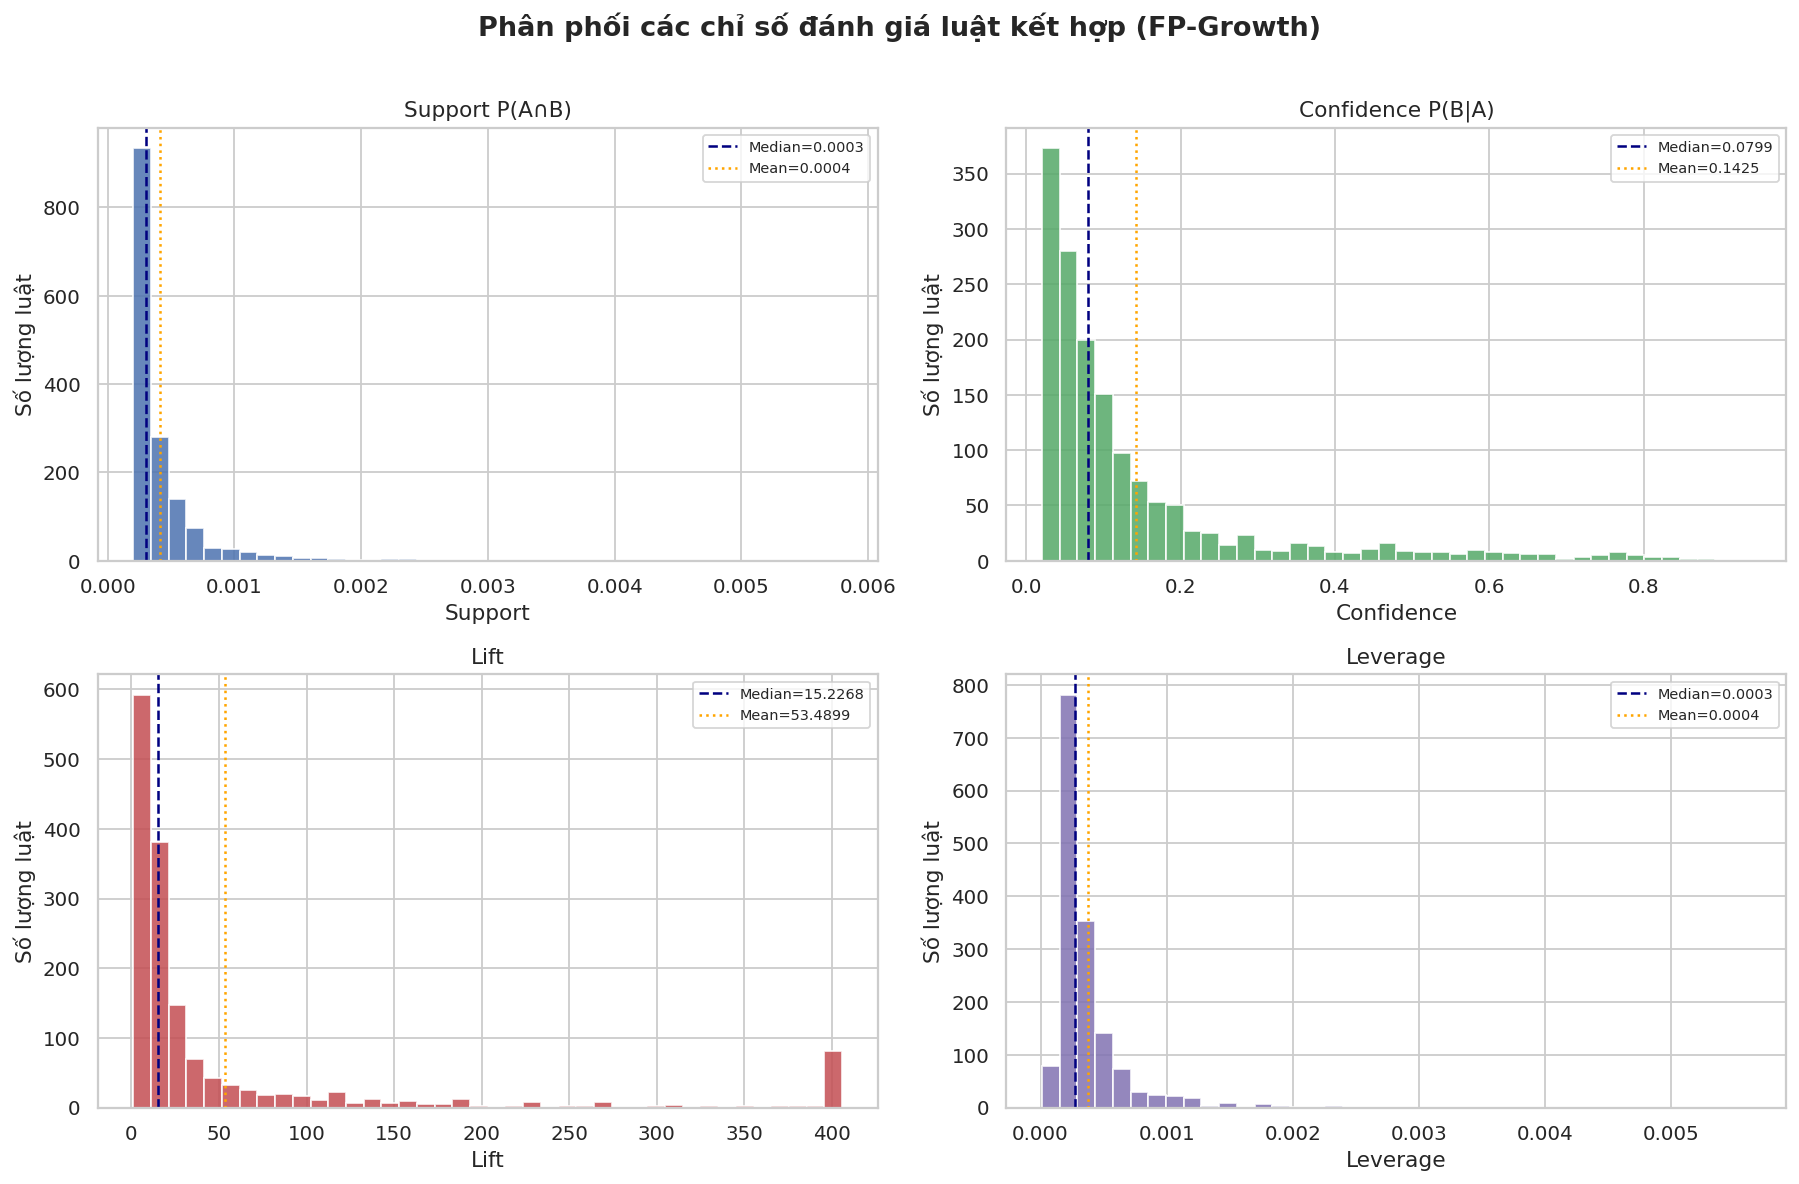

 Đã lưu: chart_01_distributions.png


In [ ]:
# ============================================================
# BƯỚC 4: BIỂU ĐỒ 1 — PHÂN PHỐI Support, Confidence, Lift, Leverage
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Phân phối các chỉ số đánh giá luật kết hợp (FP-Growth)",
 fontsize=15, fontweight="bold", y=1.01)

metrics_cfg = [
 ("support", axes[0, 0], "#4C72B0", "Support P(A∩B)"),
 ("confidence", axes[0, 1], "#55A868", "Confidence P(B|A)"),
 ("lift", axes[1, 0], "#C44E52", "Lift"),
 ("leverage", axes[1, 1], "#8172B2", "Leverage"),
]

for col, ax, color, title in metrics_cfg:
    data = df_plot[col].dropna()
    if col == "lift":
        data = data.clip(upper=data.quantile(0.95)) # Clip outlier lift
    ax.hist(data, bins=40, color=color, edgecolor="white", alpha=0.85)
    median_val = data.median()
    mean_val = data.mean()
    ax.axvline(median_val, color="navy", linestyle="--", linewidth=1.4, label=f"Median={median_val:.4f}")
    ax.axvline(mean_val, color="orange", linestyle=":", linewidth=1.4, label=f"Mean={mean_val:.4f}")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Số lượng luật")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/chart_01_distributions.png", bbox_inches="tight", dpi=130)
plt.show()
print(" Đã lưu: chart_01_distributions.png")

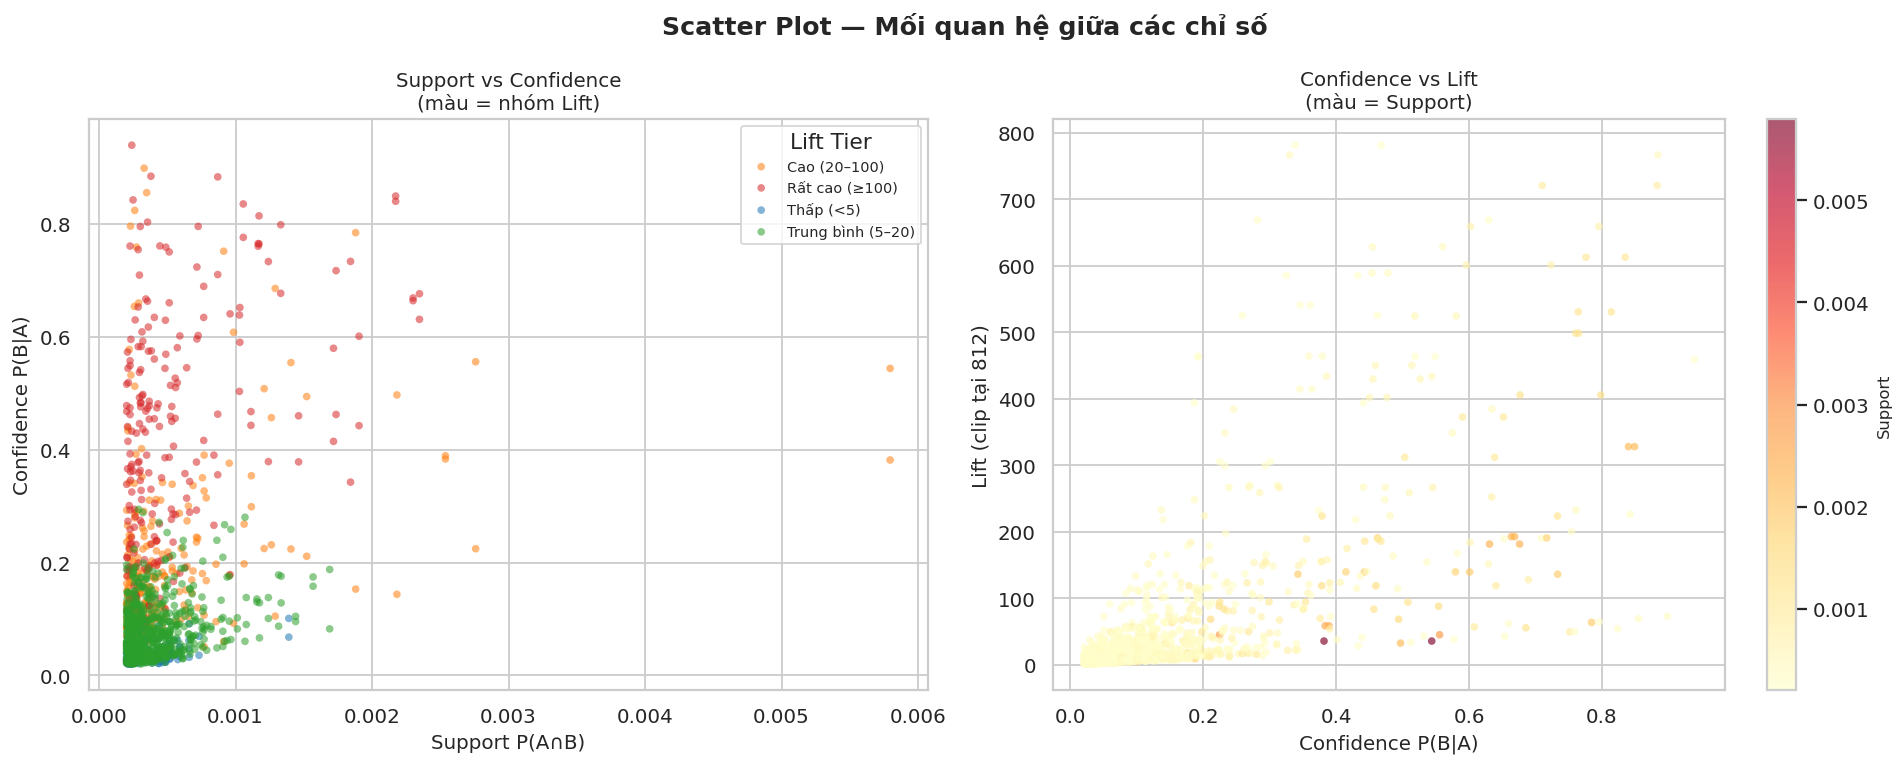

 Đã lưu: chart_02_scatter.png


In [ ]:
# ============================================================
# BIỂU ĐỒ 2 — SCATTER: Support vs Confidence vs Lift
# ============================================================
tier_colors = {
 "Rất cao (≥100)": "#d62728",
 "Cao (20–100)": "#ff7f0e",
 "Trung bình (5–20)": "#2ca02c",
 "Thấp (<5)": "#1f77b4",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Scatter Plot — Mối quan hệ giữa các chỉ số", fontsize=14, fontweight="bold")

# Plot 1: Support vs Confidence, tô màu theo Lift tier
ax = axes[0]
for tier, grp in df_plot.groupby("lift_tier"):
 ax.scatter(grp["support"], grp["confidence"],
 c=tier_colors.get(tier, "gray"),
 alpha=0.55, s=18, label=tier, edgecolors="none")
ax.set_xlabel("Support P(A∩B)", fontsize=11)
ax.set_ylabel("Confidence P(B|A)", fontsize=11)
ax.set_title("Support vs Confidence\n(màu = nhóm Lift)", fontsize=11)
ax.legend(title="Lift Tier", fontsize=8)

# Plot 2: Confidence vs Lift, tô màu theo Support
ax = axes[1]
lift_cap = df_plot["lift"].quantile(0.98)
df_tmp = df_plot[df_plot["lift"] <= lift_cap]
sc = ax.scatter(df_tmp["confidence"], df_tmp["lift"],
 c=df_tmp["support"], cmap="YlOrRd",
 alpha=0.65, s=18, edgecolors="none")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Support", fontsize=9)
ax.set_xlabel("Confidence P(B|A)", fontsize=11)
ax.set_ylabel(f"Lift (clip tại {lift_cap:.0f})", fontsize=11)
ax.set_title("Confidence vs Lift\n(màu = Support)", fontsize=11)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/chart_02_scatter.png", bbox_inches="tight", dpi=130)
plt.show()
print(" Đã lưu: chart_02_scatter.png")


In [ ]:
# ============================================================
# BẢNG TOP 10 LUẬT THEO TỪNG CHỈ SỐ
# ============================================================
for sort_col in ["lift", "confidence", "leverage", "zhang"]:
 print(f"\n{'='*60}")
 print(f" TOP 10 LUẬT THEO {sort_col.upper()}")
 print(f"{'='*60}")
 (
 rules_ext
 .orderBy(F.col(sort_col).desc())
 .select(
 "antecedent", "consequent",
 F.round("support", 4).alias("support"),
 F.round("confidence", 4).alias("conf"),
 F.round("lift", 2).alias("lift"),
 F.round("leverage", 6).alias("leverage"),
 F.round("zhang", 4).alias("zhang"),
 )
 .limit(10)
 .show(truncate=35)
 )



 TOP 10 LUẬT THEO LIFT
+----------+----------+-------+------+-------+--------+------+
|antecedent|consequent|support|  conf|   lift|leverage| zhang|
+----------+----------+-------+------+-------+--------+------+
| [0909827]| [0909823]| 2.0E-4|0.5573|1862.14| 2.27E-4|0.9999|
| [0909823]| [0909827]| 2.0E-4|0.7604|1862.14| 2.27E-4|0.9998|
| [0725663]| [0725662]| 4.0E-4|0.6628|1497.34| 3.55E-4|0.9999|
| [0725662]| [0725663]| 4.0E-4|0.8028|1497.34| 3.55E-4|0.9998|
| [0841565]| [0913540]| 3.0E-4|0.4826|1268.96| 3.02E-4|0.9998|
| [0913540]| [0841565]| 3.0E-4|0.7951|1268.96| 3.02E-4|0.9996|
| [0917300]| [0917297]| 2.0E-4|0.4779|1216.85| 2.02E-4|0.9996|
| [0917297]| [0917300]| 2.0E-4|0.5159|1216.85| 2.02E-4|0.9996|
| [0903590]| [0933889]| 2.0E-4| 0.544|1064.11| 2.12E-4|0.9994|
| [0933889]| [0903590]| 2.0E-4|0.4146|1064.11| 2.12E-4|0.9996|
+----------+----------+-------+------+-------+--------+------+


 TOP 10 LUẬT THEO CONFIDENCE
+------------------+----------+-------+------+------+--------+-

In [ ]:
# ============================================================
# BÁO CÁO CHẤT LƯỢNG MÔ HÌNH TỔNG HỢP
# ============================================================
total = len(df_plot)
thresholds = [
 ("Lift > 1 (tốt hơn random)", df_plot["lift"] > 1),
 ("Lift > 5 (mạnh)", df_plot["lift"] > 5),
 ("Lift > 20 (rất mạnh)", df_plot["lift"] > 20),
 ("Lift > 100 (cực mạnh)", df_plot["lift"] > 100),
 ("Confidence > 0.1", df_plot["confidence"] > 0.1),
 ("Confidence > 0.3", df_plot["confidence"] > 0.3),
 ("Confidence > 0.5", df_plot["confidence"] > 0.5),
 ("Leverage > 0 (tích cực)", df_plot["leverage"] > 0),
 ("Zhang > 0 (tích cực)", df_plot["zhang"] > 0),
 ("Conviction > 1 (tin tưởng được)", df_plot["conviction_capped"] > 1),
]

print(f"\n{'='*55}")
print(" BÁO CÁO CHẤT LƯỢNG MÔ HÌNH FP-GROWTH")
print(f" Tổng số luật: {total:,}")
print(f"{'='*55}")
print(f" {'Ngưỡng':<38} {'Số luật':>7} {'Tỉ lệ':>6}")
print(f" {'-'*53}")
for label, mask in thresholds:
 n = mask.sum()
 pct = n / total * 100
 print(f" {label:<38} {n:>7,} {pct:>5.1f}%")
print(f"{'='*55}")

good_ratio = (df_plot["lift"] > 5).mean()
print("\n Kết luận:")
if good_ratio > 0.7:
 print(f" Mô hình TỐT — {good_ratio*100:.1f}% luật có Lift > 5")
elif good_ratio > 0.4:
 print(f" ️ Mô hình TRUNG BÌNH — {good_ratio*100:.1f}% luật có Lift > 5")
 print(" Cân nhắc tăng MIN_SUPPORT để lọc bớt luật yếu.")
else:
 print(f" Nhiều luật yếu — chỉ {good_ratio*100:.1f}% có Lift > 5")
 print(" Hãy tăng MIN_CONFIDENCE hoặc MIN_SUPPORT.")



 BÁO CÁO CHẤT LƯỢNG MÔ HÌNH FP-GROWTH
 Tổng số luật: 1,558
 Ngưỡng                                 Số luật  Tỉ lệ
 -----------------------------------------------------
 Lift > 1 (tốt hơn random)                1,558 100.0%
 Lift > 5 (mạnh)                          1,328  85.2%
 Lift > 20 (rất mạnh)                       605  38.8%
 Lift > 100 (cực mạnh)                      220  14.1%
 Confidence > 0.1                           626  40.2%
 Confidence > 0.3                           191  12.3%
 Confidence > 0.5                            94   6.0%
 Leverage > 0 (tích cực)                  1,558 100.0%
 Zhang > 0 (tích cực)                     1,558 100.0%
 Conviction > 1 (tin tưởng được)          1,558 100.0%

 Kết luận:
 Mô hình TỐT — 85.2% luật có Lift > 5


---
## Đánh Giá Kết Quả Top-50 Gợi Ý — Tuần 7 (Ground Truth)
> Dùng dữ liệu mua thực tế của **tuần 7** làm *ground truth*, tính: **Precision@K, Recall@K, Hit Rate@K, F1@K, NDCG@K, Coverage**


In [ ]:
# ============================================================
# BƯỚC 5: GROUND TRUTH TUẦN 7
# ============================================================
week7_start = test_start_date
week7_end = test_start_date + datetime.timedelta(days=7)
print(f" Ground truth tuần 7: {week7_start} → {week7_end}")

df_week7 = (
 df
 .filter(
 (F.col("t_dat_date") >= week7_start) &
 (F.col("t_dat_date") < week7_end)
 )
)

# Ground truth: tập sản phẩm mỗi user thực sự mua trong tuần 7
gt = (
 df_week7
 .groupBy("customer_id")
 .agg(F.collect_set("article_id_str").alias("actual"))
)
gt.cache()
total_gt_users = gt.count()
print(f" Số user có mua trong tuần 7: {total_gt_users:,}")
gt.show(5, truncate=80)


 Ground truth tuần 7: 2020-09-15 → 2020-09-22
 Số user có mua trong tuần 7: 67,144
+----------------------------------------------------------------+---------------------------+
|                                                     customer_id|                     actual|
+----------------------------------------------------------------+---------------------------+
|004432f08708cc4997463536d848b960b3752dbbfa66aeede7998700c5e81552|                  [0933406]|
|00b5b1e77a0af80ed6f8aa472b03125059ef0e9cf8920e357efd2ee7297a7077|                  [0863583]|
|021aeb0e4ab083f1b8b52a4544a582dacabd1946f069de950e034d6ac5984226|                  [0873278]|
|032e069cc3127b0c9c421c36150a8a6cdb7a32c2f501da6182566a943eda6a6a|[0835348, 0926502, 0918890]|
|03cbb6ef35c9d7f4d53ee1715f438d495e3d884af5c18ad7740f21be9a02fc4b|                  [0818397]|
+----------------------------------------------------------------+---------------------------+
only showing top 5 rows


In [ ]:
# ============================================================
# BƯỚC 6: JOIN DỰ ĐOÁN × GROUND TRUTH & LỌC TRIVIAL HITS
# ============================================================
# Lấy lịch sử train của từng user để loại bỏ "trivial hit"
# (sản phẩm user đã mua rồi không nên tính là gợi ý mới)
train_history = (
 train_raw
 .groupBy("customer_id")
 .agg(F.collect_set("article_id_str").alias("train_items"))
)

eval_df = (
 association_candidates # customer_id, fp_candidates
 .join(gt, on="customer_id", how="inner") # Chỉ giữ user có ground truth
 .join(train_history, on="customer_id", how="left") # Thêm lịch sử train
 .withColumn(
 "pred_filtered",
 F.array_except("fp_candidates", "train_items") # Lọc trivial items
 )
 .drop("train_items")
)

eval_df.cache()
n_eval = eval_df.count()
print(f" Số user đánh giá được: {n_eval:,}")
print(f" ({n_eval/total_gt_users*100:.1f}% user mua tuần 7 có trong bộ gợi ý)")
eval_df.select("customer_id", "pred_filtered", "actual").show(3, truncate=60)


 Số user đánh giá được: 26,089
 (38.9% user mua tuần 7 có trong bộ gợi ý)
+------------------------------------------------------------+------------------------------------------------------------+---------------------------+
|                                                 customer_id|                                               pred_filtered|                     actual|
+------------------------------------------------------------+------------------------------------------------------------+---------------------------+
|00b5b1e77a0af80ed6f8aa472b03125059ef0e9cf8920e357efd2ee72...|      [0751471, 0762846, 0783346, 0568601, 0568597, 0889456]|                  [0863583]|
|032e069cc3127b0c9c421c36150a8a6cdb7a32c2f501da6182566a943...|[0748355, 0860797, 0506098, 0751471, 0706016, 0762846, 08...|[0835348, 0926502, 0918890]|
|03cbb6ef35c9d7f4d53ee1715f438d495e3d884af5c18ad7740f21be9...|               [0706016, 0914441, 0562245, 0867969, 0751471]|                  [0818397]|
+-------------

In [ ]:
# ============================================================
# BƯỚC 7: TÍNH CÁC CHỈ SỐ ĐÁNH GIÁ THEO K
# Precision@K, Recall@K, Hit Rate@K, NDCG@K
# ============================================================
K_LIST = [5, 10, 20, 50]

# --- Định nghĩa các hàm tính chỉ số ---
def precision_at_k(pred, actual, k):
 """Tỉ lệ sản phẩm đúng trong top-K gợi ý"""
 if not pred or not actual: return 0.0
 return len(set(pred[:k]) & set(actual)) / k

def recall_at_k(pred, actual, k):
 """Tỉ lệ sản phẩm đúng tìm được / tổng sản phẩm user thực mua"""
 if not pred or not actual: return 0.0
 return len(set(pred[:k]) & set(actual)) / len(actual)

def hit_at_k(pred, actual, k):
 """1 nếu có ít nhất 1 sản phẩm đúng trong top-K, ngược lại 0"""
 if not pred or not actual: return 0.0
 return 1.0 if set(pred[:k]) & set(actual) else 0.0

def ndcg_at_k(pred, actual, k):
 """Normalized Discounted Cumulative Gain — đánh giá chất lượng xếp hạng"""
 if not pred or not actual: return 0.0
 actual_set = set(actual)
 dcg = sum(1.0 / math.log2(i + 2) for i, p in enumerate(pred[:k]) if p in actual_set)
 idcg = sum(1.0 / math.log2(i + 2) for i in range(min(len(actual_set), k)))
 return dcg / idcg if idcg > 0 else 0.0

# --- Đăng ký UDF và tính cho mỗi K ---
metrics_cols = []
df_metrics = eval_df

for k in K_LIST:
 p_udf = udf(lambda pred, actual, _k=k: precision_at_k(pred, actual, _k), DoubleType())
 r_udf = udf(lambda pred, actual, _k=k: recall_at_k(pred, actual, _k), DoubleType())
 h_udf = udf(lambda pred, actual, _k=k: hit_at_k(pred, actual, _k), DoubleType())
 n_udf = udf(lambda pred, actual, _k=k: ndcg_at_k(pred, actual, _k), DoubleType())

 df_metrics = (
 df_metrics
 .withColumn(f"P@{k}", p_udf("pred_filtered", "actual"))
 .withColumn(f"R@{k}", r_udf("pred_filtered", "actual"))
 .withColumn(f"Hit@{k}", h_udf("pred_filtered", "actual"))
 .withColumn(f"NDCG@{k}", n_udf("pred_filtered", "actual"))
 )
 metrics_cols += [f"P@{k}", f"R@{k}", f"Hit@{k}", f"NDCG@{k}"]

df_metrics = df_metrics.withColumn("pred_len", F.size("pred_filtered"))
df_metrics.cache()
print(" Đã tính xong các chỉ số — đang tổng hợp...")


 Đã tính xong các chỉ số — đang tổng hợp...


In [ ]:
# ============================================================
# BƯỚC 8: BẢNG KẾT QUẢ TỔNG HỢP + COVERAGE
# ============================================================
agg_exprs = [F.mean(c).alias(c) for c in metrics_cols]
result_row = df_metrics.agg(*agg_exprs).collect()[0].asDict()

rows = []
for k in K_LIST:
 p = result_row[f"P@{k}"]
 r = result_row[f"R@{k}"]
 h = result_row[f"Hit@{k}"]
 n = result_row[f"NDCG@{k}"]
 f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
 rows.append({"K": k,
 "Precision@K": round(p, 4),
 "Recall@K": round(r, 4),
 "F1@K": round(f1, 4),
 "Hit Rate@K": round(h, 4),
 "NDCG@K": round(n, 4)})

df_result = pd.DataFrame(rows).set_index("K")

print("=" * 62)
print(" KẾT QUẢ ĐÁNH GIÁ FP-GROWTH TOP-50 TRÊN TUẦN 7")
print(f" Số user đánh giá: {n_eval:,} | Ground truth: {total_gt_users:,} users")
print("=" * 62)
print(df_result.to_string())
print("=" * 62)

# Catalog Coverage
all_recommended = (
 df_metrics
 .select(F.explode("pred_filtered").alias("item"))
 .distinct().count()
)
all_catalog = train_raw.select("article_id_str").distinct().count()
coverage = all_recommended / all_catalog * 100

avg_pred_len = df_metrics.agg(F.mean("pred_len")).collect()[0][0]

print(f"\n Catalog Coverage: {all_recommended:,} / {all_catalog:,} SP = {coverage:.2f}%")
print(f" Avg gợi ý sau lọc train: {avg_pred_len:.1f} SP/user")


 KẾT QUẢ ĐÁNH GIÁ FP-GROWTH TOP-50 TRÊN TUẦN 7
 Số user đánh giá: 26,089 | Ground truth: 67,144 users
    Precision@K  Recall@K    F1@K  Hit Rate@K  NDCG@K
K                                                    
5        0.0104    0.0202  0.0137      0.0488  0.0169
10       0.0082    0.0301  0.0129      0.0740  0.0205
20       0.0055    0.0398  0.0097      0.0946  0.0237
50       0.0025    0.0437  0.0047      0.1039  0.0248

 Catalog Coverage: 436 / 16,872 SP = 2.58%
 Avg gợi ý sau lọc train: 12.3 SP/user



 KẾT QUẢ THEO NHÓM USER (K=10 và K=50):
+----------------+-------+------+------+------+-------+------+------+
|user_segment    |n_users|P@10  |R@10  |Hit@10|NDCG@10|P@50  |Hit@50|
+----------------+-------+------+------+------+-------+------+------+
|Medium (4–10 SP)|12516  |0.0083|0.0301|0.0755|0.0202 |0.0025|0.1039|
|Light (2–3 SP)  |6449   |0.0077|0.034 |0.0702|0.0233 |0.0019|0.0828|
|Heavy (>10 SP)  |4870   |0.009 |0.0227|0.0789|0.0155 |0.0037|0.1466|
|Cold (1 SP)     |2254   |0.007 |0.035 |0.0657|0.0257 |0.0016|0.0723|
+----------------+-------+------+------+------+-------+------+------+



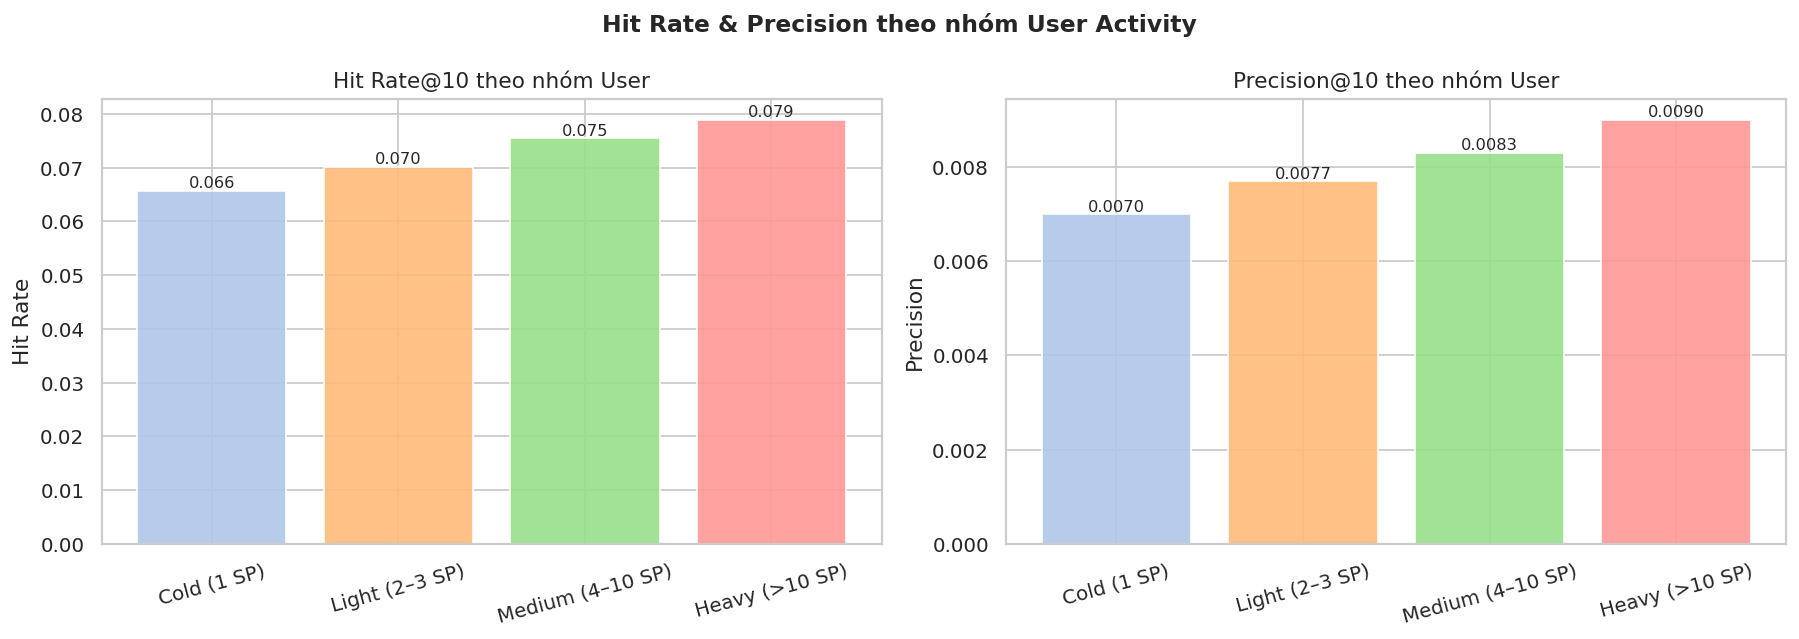

 Đã lưu: chart_w7_segment.png


In [ ]:
# ============================================================
# PHÂN TÍCH THEO NHÓM USER (Cold / Light / Medium / Heavy)
# ============================================================
user_activity = (
 train_raw
 .groupBy("customer_id")
 .agg(F.countDistinct("article_id_str").alias("n_train_items"))
 .withColumn("user_segment",
 F.when(F.col("n_train_items") == 1, "Cold (1 SP)")
 .when(F.col("n_train_items") <= 3, "Light (2–3 SP)")
 .when(F.col("n_train_items") <= 10, "Medium (4–10 SP)")
 .otherwise("Heavy (>10 SP)")
 )
)

seg_result = (
 df_metrics
 .join(user_activity.select("customer_id", "user_segment"), on="customer_id", how="left")
 .groupBy("user_segment")
 .agg(
 F.count("*").alias("n_users"),
 F.round(F.mean("P@10"), 4).alias("P@10"),
 F.round(F.mean("R@10"), 4).alias("R@10"),
 F.round(F.mean("Hit@10"), 4).alias("Hit@10"),
 F.round(F.mean("NDCG@10"), 4).alias("NDCG@10"),
 F.round(F.mean("P@50"), 4).alias("P@50"),
 F.round(F.mean("Hit@50"), 4).alias("Hit@50"),
 )
 .orderBy("n_users", ascending=False)
)

print("\n KẾT QUẢ THEO NHÓM USER (K=10 và K=50):")
seg_result.show(truncate=False)

# Biểu đồ
seg_pd = seg_result.toPandas()
seg_order = ["Cold (1 SP)", "Light (2–3 SP)", "Medium (4–10 SP)", "Heavy (>10 SP)"]
seg_pd["user_segment"] = pd.Categorical(seg_pd["user_segment"], categories=seg_order, ordered=True)
seg_pd = seg_pd.sort_values("user_segment")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Hit Rate & Precision theo nhóm User Activity", fontsize=13, fontweight="bold")

bar_colors = ["#aec7e8", "#ffbb78", "#98df8a", "#ff9896"]
x = range(len(seg_pd))

axes[0].bar(x, seg_pd["Hit@10"], color=bar_colors, edgecolor="white", alpha=0.9)
axes[0].bar_label(axes[0].containers[0], fmt="%.3f", fontsize=9)
axes[0].set_xticks(x); axes[0].set_xticklabels(seg_pd["user_segment"], rotation=15)
axes[0].set_title("Hit Rate@10 theo nhóm User"); axes[0].set_ylabel("Hit Rate")

axes[1].bar(x, seg_pd["P@10"], color=bar_colors, edgecolor="white", alpha=0.9)
axes[1].bar_label(axes[1].containers[0], fmt="%.4f", fontsize=9)
axes[1].set_xticks(x); axes[1].set_xticklabels(seg_pd["user_segment"], rotation=15)
axes[1].set_title("Precision@10 theo nhóm User"); axes[1].set_ylabel("Precision")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/chart_w7_segment.png", bbox_inches="tight", dpi=130)
plt.show()
print(" Đã lưu: chart_w7_segment.png")


In [ ]:
# ============================================================
# TÓM TẮT & NHẬN XÉT TỰ ĐỘNG
# ============================================================
p10 = df_result.loc[10, "Precision@K"]
r10 = df_result.loc[10, "Recall@K"]
h10 = df_result.loc[10, "Hit Rate@K"]
n10 = df_result.loc[10, "NDCG@K"]
h50 = df_result.loc[50, "Hit Rate@K"]

print("=" * 60)
print(" NHẬN XÉT TỰ ĐỘNG — FP-GROWTH CROSS-SELL WEEK 7")
print("=" * 60)
print(f" Hit Rate@10 = {h10:.4f} → {h10*100:.1f}% user có ít nhất 1 hit trong top-10")
print(f" Hit Rate@50 = {h50:.4f} → {h50*100:.1f}% user có ít nhất 1 hit trong top-50")
print(f" Precision@10 = {p10:.4f} → trung bình {p10*10:.2f}/10 gợi ý đúng")
print(f" Recall@10 = {r10:.4f} → tìm được {r10*100:.1f}% SP user thực mua")
print(f" NDCG@10 = {n10:.4f} → chất lượng xếp hạng (0–1)")
print(f" Coverage = {coverage:.2f}% → đa dạng gợi ý")
print()

if h10 >= 0.15:
 print(" Hit Rate@10 tốt (≥15%) — mô hình capture được xu hướng mua kèm.")
elif h10 >= 0.05:
 print(" ️ Hit Rate@10 trung bình (5–15%) — có thể cải thiện bằng cách:")
 print(" • Tăng TRAIN_WEEKS (8–12 tuần) để học thêm mẫu")
 print(" • Hạ MIN_CONFIDENCE để sinh thêm gợi ý")
 print(" • Kết hợp ALS để bù đắp cold-user")
else:
 print(" Hit Rate@10 thấp (<5%) — xem xét:")
 print(" • Hạ MIN_SUPPORT và MIN_CONFIDENCE")
 print(" • Kiểm tra xem tuần 7 có seasonal shift không")
 print(" • Dùng basket theo tuần thay vì ngày")

if coverage >= 10:
 print(f" Coverage {coverage:.1f}% — gợi ý đa dạng.")
else:
 print(f" ️ Coverage {coverage:.1f}% thấp — tập trung vào ít mặt hàng phổ biến.")
print("=" * 60)


 NHẬN XÉT TỰ ĐỘNG — FP-GROWTH CROSS-SELL WEEK 7
 Hit Rate@10 = 0.0740 → 7.4% user có ít nhất 1 hit trong top-10
 Hit Rate@50 = 0.1039 → 10.4% user có ít nhất 1 hit trong top-50
 Precision@10 = 0.0082 → trung bình 0.08/10 gợi ý đúng
 Recall@10 = 0.0301 → tìm được 3.0% SP user thực mua
 NDCG@10 = 0.0205 → chất lượng xếp hạng (0–1)
 Coverage = 2.58% → đa dạng gợi ý

 ️ Hit Rate@10 trung bình (5–15%) — có thể cải thiện bằng cách:
 • Tăng TRAIN_WEEKS (8–12 tuần) để học thêm mẫu
 • Hạ MIN_CONFIDENCE để sinh thêm gợi ý
 • Kết hợp ALS để bù đắp cold-user
 ️ Coverage 2.6% thấp — tập trung vào ít mặt hàng phổ biến.
